# CLIP Prompt Tuning · 遥感图文检索


In [1]:
import os
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'

# ── 安装依赖 ──────────────────────────────────────────
!pip install open_clip_torch grad-cam tifffile -q
print("✅ 依赖安装完成")


✅ 依赖安装完成


In [2]:
import torch

SAVE_DIR  = '/root/autodl-tmp/remote_clip'
JSON_PATH = '/root/autodl-tmp/dataset_RSITMD.json'
IMG_DIR   = '/root/autodl-tmp/images'

os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ 设备: {device}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✅ 显存: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


✅ 设备: cuda
✅ GPU: NVIDIA vGPU-48GB
✅ 显存: 50.9 GB


In [3]:
import json
import numpy as np
from PIL import Image
import tifffile
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F


class RSITMDTrainDataset(Dataset):
    """训练集：每条 (image, caption) 一对"""
    def __init__(self, json_path, img_dir, preprocess):
        with open(json_path, 'r') as f:
            data = json.load(f)
        self.img_dir    = img_dir
        self.preprocess = preprocess
        self.samples = []
        for item in data['images']:
            if item['split'] == 'train':
                for sent in item['sentences']:
                    self.samples.append((item['filename'], sent['raw']))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        fname, caption = self.samples[idx]
        img = self._load_image(os.path.join(self.img_dir, fname))
        return self.preprocess(img), caption

    def _load_image(self, path):
        try:
            arr = tifffile.imread(path)
            if arr.dtype != np.uint8:
                arr = (arr / arr.max() * 255).astype(np.uint8)
            if arr.ndim == 2:
                arr = np.stack([arr]*3, axis=-1)
            return Image.fromarray(arr).convert('RGB')
        except Exception:
            return Image.open(path).convert('RGB')


class RSITMDDatasetFull(Dataset):
    """测试集：每张图返回 5 条描述"""
    def __init__(self, json_path, img_dir, preprocess, split='test'):
        with open(json_path, 'r') as f:
            data = json.load(f)
        self.img_dir    = img_dir
        self.preprocess = preprocess
        self.data = [item for item in data['images'] if item['split'] == split]

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        item  = self.data[idx]
        img   = self._load_image(os.path.join(self.img_dir, item['filename']))
        caps  = [item['sentences'][j]['raw'] for j in range(5)]
        return self.preprocess(img), caps

    def _load_image(self, path):
        try:
            arr = tifffile.imread(path)
            if arr.dtype != np.uint8:
                arr = (arr / arr.max() * 255).astype(np.uint8)
            if arr.ndim == 2:
                arr = np.stack([arr]*3, axis=-1)
            return Image.fromarray(arr).convert('RGB')
        except Exception:
            return Image.open(path).convert('RGB')

def compute_recall_bidirectional(img_feats, txt_feats, k_vals=(1, 5, 10)):
    """
    双向检索 Recall@K
    img_feats: [N, D]      已 L2 归一化
    txt_feats: [N, 5, D]   已 L2 归一化，每图 5 条 GT 描述
    """
    img_feats = img_feats.to(img_feats.device)
    N = img_feats.shape[0]
    txt_flat = txt_feats.reshape(N * 5, -1).to(img_feats.device)  # [5N, D]

    # ── 图 → 文 ──
    sim_i2t = img_feats @ txt_flat.T                              # [N, 5N]
    i2t = {}
    for k in k_vals:
        topk = sim_i2t.topk(k, dim=1).indices
        gt_start = torch.arange(N, device=img_feats.device).unsqueeze(1) * 5
        gt_end   = gt_start + 5
        hit = ((topk >= gt_start) & (topk < gt_end)).any(dim=1)
        i2t[f'R@{k}'] = hit.float().mean().item() * 100

    # ── 文 → 图 ──
    sim_t2i = txt_flat @ img_feats.T                              # [5N, N]
    t2i = {}
    # 每条文本 j 的 GT 图像 idx = j // 5
    gt_img = (torch.arange(5 * N, device=img_feats.device) // 5).unsqueeze(1)  # [5N, 1]
    for k in k_vals:
        topk = sim_t2i.topk(k, dim=1).indices                     # [5N, k]
        hit  = (topk == gt_img).any(dim=1)
        t2i[f'R@{k}'] = hit.float().mean().item() * 100

    return {'i2t': i2t, 't2i': t2i}


# 兼容老代码：保留原函数名，返回 i2t 部分
def compute_recall_rsitmd(img_feats, txt_feats, k_vals=(1, 5, 10)):
    return compute_recall_bidirectional(img_feats, txt_feats, k_vals)['i2t']

print("✅ 数据集类与召回率函数定义完成")


✅ 数据集类与召回率函数定义完成


In [4]:
import open_clip

model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai')
tokenizer = open_clip.get_tokenizer('ViT-B-32')
model.eval().to(device)

train_dataset     = RSITMDTrainDataset(JSON_PATH, IMG_DIR, preprocess)
test_dataset_full = RSITMDDatasetFull(JSON_PATH, IMG_DIR, preprocess, split='test')

train_loader = DataLoader(
    train_dataset, batch_size=64,
    shuffle=True, num_workers=4, pin_memory=True)
test_loader_full = DataLoader(
    test_dataset_full, batch_size=64,
    shuffle=False, num_workers=4)

print(f"✅ 训练集样本数: {len(train_dataset)}")
print(f"✅ 测试集图像数: {len(test_dataset_full)}")


/root/miniconda3/lib/python3.8/site-packages/open_clip/factory.py:388: UserWarning: These pretrained weights were trained with QuickGELU activation but the model config does not have that enabled. Consider using a model config with a "-quickgelu" suffix or enable with a flag.
  warnings.warn(


✅ 训练集样本数: 21455
✅ 测试集图像数: 452


In [5]:
from tqdm import tqdm

model.eval()
all_img_feats, all_txt_feats = [], []

with torch.no_grad():
    for imgs, caps_list in tqdm(test_loader_full, desc="基线评估"):
        imgs = imgs.to(device)
        img_feat = F.normalize(model.encode_image(imgs).float(), dim=-1)
        all_img_feats.append(img_feat.cpu())

        # caps_list 是 default_collate 后的 list of 5 tuples，每个 tuple 长度 = batch
        # 拍平成 batch * 5 条文本一次性 tokenize
        B = imgs.size(0)
        flat_caps = [caps_list[j][i] for i in range(B) for j in range(5)]   # 5*B 条
        tokens = tokenizer(flat_caps).to(device)
        feats  = F.normalize(model.encode_text(tokens).float(), dim=-1)     # [5B, D]
        feats  = feats.view(B, 5, -1).cpu()                                  # [B, 5, D]
        all_txt_feats.append(feats)

all_img = torch.cat(all_img_feats, dim=0)
all_txt = torch.cat(all_txt_feats, dim=0)

baseline_full = compute_recall_bidirectional(all_img, all_txt)
baseline = baseline_full['i2t']               
print(f"\n📊 零样本基线（图→文）: {baseline_full['i2t']}")
print(f"📊 零样本基线（文→图）: {baseline_full['t2i']}")


基线评估: 100%|██████████| 8/8 [00:01<00:00,  4.63it/s]


📊 零样本基线（图→文）: {'R@1': 8.628318458795547, 'R@5': 22.123894095420837, 'R@10': 32.07964599132538}
📊 零样本基线（文→图）: {'R@1': 7.92035385966301, 'R@5': 25.79646110534668, 'R@10': 41.7256623506546}



/tmp/ipykernel_4622/4072104675.py:93: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  gt_img = (torch.arange(5 * N, device=img_feats.device) // 5).unsqueeze(1)  # [5N, 1]


In [6]:
import torch.nn as nn


class LearnablePrompt(nn.Module):
    def __init__(self, n_ctx=8, ctx_dim=512):
        super().__init__()
        ctx_vectors = torch.empty(n_ctx, ctx_dim)
        nn.init.normal_(ctx_vectors, std=0.02)
        self.ctx   = nn.Parameter(ctx_vectors)
        self.n_ctx = n_ctx


class PromptCLIP(nn.Module):
    def __init__(self, clip_model, tokenizer, n_ctx=8, device='cuda'):
        super().__init__()
        self.clip      = clip_model
        self.tokenizer = tokenizer
        self.device    = device
        self.n_ctx     = n_ctx

        ctx_dim     = clip_model.token_embedding.embedding_dim
        self.prompt = LearnablePrompt(n_ctx=n_ctx, ctx_dim=ctx_dim)

        # 冻结 CLIP，仅训练 ctx
        for p in self.clip.parameters():
            p.requires_grad = False
        self.prompt.ctx.requires_grad = True

        # 自适应判断 transformer 是否 batch_first（关键修复 ①）
        self._txt_batch_first = getattr(self.clip.transformer, 'batch_first', True)

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f"✅ 可训练参数: {trainable:,} / {total:,} ({100*trainable/total:.3f}%)")
        print(f"✅ transformer.batch_first = {self._txt_batch_first}")

    # ----------------------------------------------------------------
    # 关键：把可学习 ctx 插到 SOS 之后，再走文本编码器
    # ----------------------------------------------------------------
    def encode_text_with_prompt(self, texts):
        tokens     = self.tokenizer(texts).to(self.device)
        cast_dtype = self.clip.transformer.get_cast_dtype()

        x = self.clip.token_embedding(tokens)                  # [B, 77, D]
        x = x.to(cast_dtype if cast_dtype is not None else x.dtype)

        B, T, D = x.shape

        ctx = self.prompt.ctx                                  # [n_ctx, D]
        if cast_dtype is not None:
            ctx = ctx.to(cast_dtype)
        ctx_expanded = ctx.unsqueeze(0).expand(B, -1, -1)      # [B, n_ctx, D]

        # 在 SOS 之后插入 prompt，截掉末尾 n_ctx 个 PAD 以保持总长 77
        prefix = x[:, :1, :]                                   # [B, 1, D]
        suffix = x[:, 1: T - self.n_ctx, :]                    # [B, T-1-n_ctx, D]
        x = torch.cat([prefix, ctx_expanded, suffix], dim=1)   # [B, T, D]

        pos_emb = self.clip.positional_embedding
        if cast_dtype is not None:
            pos_emb = pos_emb.to(cast_dtype)
        x = x + pos_emb

        attn_mask = getattr(self.clip, 'attn_mask', None)

        # ✅ 关键修复：根据 transformer 是否 batch_first 决定是否 permute
        # 新版 open_clip 默认 batch_first=True，输入应为 [B, L, D]，无需 permute
        if not self._txt_batch_first:
            x = x.permute(1, 0, 2)                             # [L, B, D]
        x = self.clip.transformer(x, attn_mask=attn_mask)
        if not self._txt_batch_first:
            x = x.permute(1, 0, 2)                             # [B, L, D]

        x = self.clip.ln_final(x)

        # EOS 位置随 ctx 插入向右偏移 n_ctx
        eos_pos = tokens.argmax(dim=-1)
        adj_pos = (eos_pos + self.n_ctx).clamp(max=T - 1)
        x = x[torch.arange(B, device=x.device), adj_pos]       # [B, D]

        # ✅ 鲁棒处理：text_projection 在不同版本可能是 Parameter 或 Linear
        proj = self.clip.text_projection
        if isinstance(proj, nn.Linear):
            x = proj(x.to(proj.weight.dtype)).float()
        else:                                                  # Parameter 或 Tensor
            x = x.float() @ proj.float()
        return x

    def forward(self, images, texts):
        with torch.no_grad():
            img_feat = self.clip.encode_image(images)
        txt_feat = self.encode_text_with_prompt(texts)
        return (F.normalize(img_feat.float(), dim=-1),
                F.normalize(txt_feat.float(), dim=-1))


prompt_model = PromptCLIP(model, tokenizer, n_ctx=8, device=device).to(device)


✅ 可训练参数: 4,096 / 151,281,409 (0.003%)
✅ transformer.batch_first = True


In [7]:
class InfoNCELoss(nn.Module):
    def __init__(self, init_temp=0.07):
        super().__init__()
        self.logit_scale = nn.Parameter(torch.tensor(1.0/init_temp).log())

    def forward(self, img_feat, txt_feat):
        scale  = self.logit_scale.exp().clamp(max=100)
        logits = scale * img_feat @ txt_feat.T
        labels = torch.arange(len(img_feat), device=img_feat.device)
        return (F.cross_entropy(logits, labels) +
                F.cross_entropy(logits.T, labels)) / 2


criterion = InfoNCELoss().to(device)


def evaluate_prompt_model(prompt_model, return_full=False):
    prompt_model.eval()
    _img, _txt = [], []
    with torch.no_grad():
        for imgs, caps_list in test_loader_full:
            imgs = imgs.to(device)
            img_feat = F.normalize(
                prompt_model.clip.encode_image(imgs).float(), dim=-1)
            _img.append(img_feat.cpu())
            B = imgs.size(0)
            flat_caps = [caps_list[j][i] for i in range(B) for j in range(5)]
            feats = prompt_model.encode_text_with_prompt(flat_caps)
            feats = F.normalize(feats.float(), dim=-1).view(B, 5, -1).cpu()
            _txt.append(feats)

    all_img = torch.cat(_img, dim=0)
    all_txt = torch.cat(_txt, dim=0)
    full = compute_recall_bidirectional(all_img, all_txt)
    return full if return_full else full['i2t']

def check_gradient():
    prompt_model.train()
    imgs, captions = next(iter(train_loader))
    img_feat, txt_feat = prompt_model(imgs.to(device), list(captions))
    loss = criterion(img_feat, txt_feat)
    loss.backward()
    grad = prompt_model.prompt.ctx.grad
    print(f"Loss:         {loss.item():.4f}  (随机猜≈{torch.log(torch.tensor(float(len(captions)))).item():.2f})")
    print(f"ctx 梯度范数: {grad.norm().item():.6f}  ← 必须 > 0")
    print(f"文本特征范数: {txt_feat.norm(dim=-1).mean().item():.4f}  ← 应≈1.0")
    prompt_model.zero_grad()


check_gradient()


Loss:         3.7861  (随机猜≈4.16)
ctx 梯度范数: 4.273992  ← 必须 > 0
文本特征范数: 1.0000  ← 应≈1.0


In [8]:
from torch.optim.lr_scheduler import CosineAnnealingLR
import time

EPOCHS = 20
LR     = 5e-4

optimizer = torch.optim.AdamW(
    [prompt_model.prompt.ctx] + list(criterion.parameters()),
    lr=LR, weight_decay=0.01)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

history    = {'loss': [], 'R@1': [], 'R@5': [], 'R@10': []}
best_r1    = baseline['R@1']
best_epoch = 0

print(f"{'Epoch':<7}{'Loss':<10}{'R@1':<10}{'R@5':<10}{'R@10':<10}{'状态'}")
print("─" * 55)

for epoch in range(1, EPOCHS + 1):
    prompt_model.train()
    epoch_loss = 0.0
    t0 = time.time()

    for imgs, captions in train_loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        img_feat, txt_feat = prompt_model(imgs, list(captions))
        loss = criterion(img_feat, txt_feat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [prompt_model.prompt.ctx] + list(criterion.parameters()), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    metrics  = evaluate_prompt_model(prompt_model)
    elapsed  = int(time.time() - t0)

    history['loss'].append(avg_loss)
    for k in ['R@1', 'R@5', 'R@10']:
        history[k].append(metrics[k])

    flag = ''
    if metrics['R@1'] > best_r1:
        best_r1, best_epoch = metrics['R@1'], epoch
        torch.save({
            'epoch': epoch,
            'ctx':   prompt_model.prompt.ctx.data.cpu(),
            'logit_scale': criterion.logit_scale.data.cpu(),
            'metrics': metrics,
        }, f'{SAVE_DIR}/best_prompt.pt')
        flag = '⭐ 最优'

    print(f"Ep{epoch:<5}{avg_loss:<10.4f}"
          f"{metrics['R@1']:<10.2f}{metrics['R@5']:<10.2f}"
          f"{metrics['R@10']:<10.2f}{flag}  ({elapsed}s)")

print(f"\n🏆 完成！最优 R@1={best_r1:.2f}（Epoch {best_epoch}）")


Epoch  Loss      R@1       R@5       R@10      状态
───────────────────────────────────────────────────────
Ep1    2.8714    10.18     25.22     36.73     ⭐ 最优  (16s)


/tmp/ipykernel_4622/4072104675.py:93: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  gt_img = (torch.arange(5 * N, device=img_feats.device) // 5).unsqueeze(1)  # [5N, 1]


Ep2    2.5459    9.51      25.44     37.39       (16s)
Ep3    2.3853    11.73     28.32     41.59     ⭐ 最优  (16s)
Ep4    2.2687    12.83     28.32     40.27     ⭐ 最优  (16s)
Ep5    2.1781    12.17     27.21     41.15       (16s)
Ep6    2.1121    12.83     28.54     41.59       (16s)
Ep7    2.0594    12.17     29.87     42.04       (16s)
Ep8    2.0193    12.83     31.19     44.91       (16s)
Ep9    1.9841    13.50     28.76     43.81     ⭐ 最优  (16s)
Ep10   1.9611    12.17     29.65     45.80       (16s)
Ep11   1.9450    12.61     32.08     46.46       (16s)
Ep12   1.9204    12.61     32.74     47.79       (16s)
Ep13   1.9023    14.16     32.96     46.24     ⭐ 最优  (16s)
Ep14   1.8826    14.38     32.30     48.23     ⭐ 最优  (16s)
Ep15   1.8780    13.50     34.07     48.01       (16s)
Ep16   1.8699    13.27     33.63     47.57       (16s)
Ep17   1.8577    12.83     34.07     48.45       (16s)
Ep18   1.8566    14.16     33.19     48.45       (16s)
Ep19   1.8499    14.82     34.29     47.57   


══════════════════════════════════════════════════════════════
  方案                              R@1      R@5     R@10
══════════════════════════════════════════════════════════════
  零样本 CLIP（基线）                   8.63    22.12    32.08
  Prompt Tuning（本方法）            14.82    34.29    48.45
──────────────────────────────────────────────────────────────
  R@1 提升: ▲ 6.19 pt  (+71.8%)
  R@5 提升: ▲ 12.17 pt  (+55.0%)
  R@10 提升: ▲ 16.37 pt  (+51.0%)
══════════════════════════════════════════════════════════════
  可训练参数: 4,096  (CLIP 全参的 0.00%)
══════════════════════════════════════════════════════════════


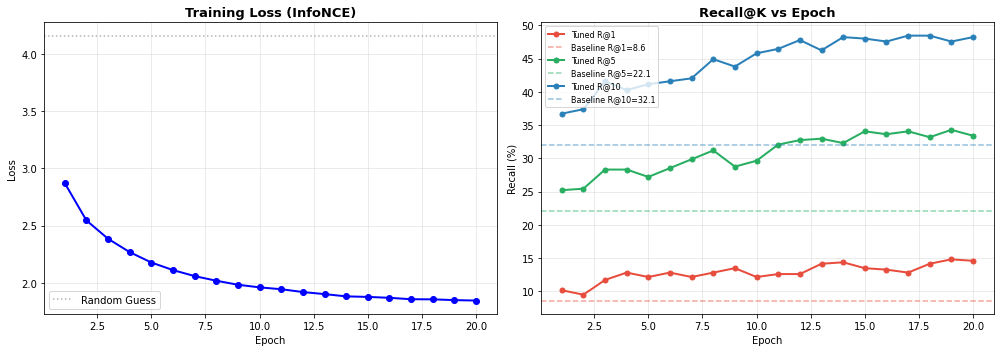

✅ 训练曲线已保存


In [9]:
import matplotlib.pyplot as plt
import matplotlib

# 中文字体兜底，避免方块
for font in ['Microsoft YaHei', 'SimHei', 'WenQuanYi Zen Hei', 'Noto Sans CJK SC', 'DejaVu Sans']:
    try:
        matplotlib.rcParams['font.sans-serif'] = [font]
        matplotlib.rcParams['axes.unicode_minus'] = False
        break
    except Exception:
        continue

best_metrics = {k: max(history[k]) for k in ['R@1', 'R@5', 'R@10']}

print("\n" + "═"*62)
print(f"  {'方案':<26} {'R@1':>8} {'R@5':>8} {'R@10':>8}")
print("═"*62)
print(f"  {'零样本 CLIP（基线）':<26} "
      f"{baseline['R@1']:>8.2f} {baseline['R@5']:>8.2f} {baseline['R@10']:>8.2f}")
print(f"  {'Prompt Tuning（本方法）':<26} "
      f"{best_metrics['R@1']:>8.2f} {best_metrics['R@5']:>8.2f} {best_metrics['R@10']:>8.2f}")
print("─"*62)
for k in ['R@1', 'R@5', 'R@10']:
    delta = best_metrics[k] - baseline[k]
    pct   = delta / baseline[k] * 100
    print(f"  {k} 提升: {'▲' if delta>0 else '▼'} {abs(delta):.2f} pt  ({pct:+.1f}%)")
print("═"*62)
trainable = sum(p.numel() for p in prompt_model.parameters() if p.requires_grad)
print(f"  可训练参数: {trainable:,}  (CLIP 全参的 {trainable/151e6*100:.2f}%)")
print("═"*62)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_x = range(1, len(history['loss']) + 1)
colors   = {'R@1': '#e74c3c', 'R@5': '#27ae60', 'R@10': '#2980b9'}

ax1.plot(epochs_x, history['loss'], 'b-o', markersize=6, linewidth=2)
ax1.set_title('Training Loss (InfoNCE)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.axhline(y=torch.log(torch.tensor(64.0)).item(),
            color='gray', linestyle=':', alpha=0.6, label='Random Guess')
ax1.legend(); ax1.grid(alpha=0.3)

for k, c in colors.items():
    ax2.plot(epochs_x, history[k], '-o', color=c,
             markersize=5, linewidth=2, label=f'Tuned {k}')
    ax2.axhline(y=baseline[k], color=c, linestyle='--',
                alpha=0.5, label=f'Baseline {k}={baseline[k]:.1f}')
ax2.set_title('Recall@K vs Epoch', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Recall (%)')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_curve.png', dpi=150)
plt.show()
print("✅ 训练曲线已保存")


In [10]:
ckpt = torch.load(f'{SAVE_DIR}/best_prompt.pt')
prompt_model.prompt.ctx.data   = ckpt['ctx'].to(device)
criterion.logit_scale.data     = ckpt['logit_scale'].to(device)
print(f"✅ 加载 Epoch {ckpt['epoch']} 最优模型")
print(f"   训练时指标: {ckpt['metrics']}")
final_full = evaluate_prompt_model(prompt_model, return_full=True)
print("微调后（图→文）:", final_full['i2t'])
print("微调后（文→图）:", final_full['t2i'])

import json
results = {
    'baseline_i2t':  baseline_full['i2t'],
    'baseline_t2i':  baseline_full['t2i'],
    'finetuned_i2t': final_full['i2t'],
    'finetuned_t2i': final_full['t2i'],
}
with open(f'{SAVE_DIR}/results_full.json', 'w') as f:
    json.dump(results, f, indent=2)
print("✅ 双向结果已保存")
final = evaluate_prompt_model(prompt_model)
print(f"   重新验证:   {final}")


✅ 加载 Epoch 19 最优模型
   训练时指标: {'R@1': 14.823009073734283, 'R@5': 34.292036294937134, 'R@10': 47.56637215614319}
微调后（图→文）: {'R@1': 14.823009073734283, 'R@5': 34.292036294937134, 'R@10': 47.56637215614319}
微调后（文→图）: {'R@1': 11.017698794603348, 'R@5': 38.84955644607544, 'R@10': 58.36282968521118}
✅ 双向结果已保存


/tmp/ipykernel_4622/4072104675.py:93: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  gt_img = (torch.arange(5 * N, device=img_feats.device) // 5).unsqueeze(1)  # [5N, 1]


   重新验证:   {'R@1': 14.823009073734283, 'R@5': 34.292036294937134, 'R@10': 47.56637215614319}


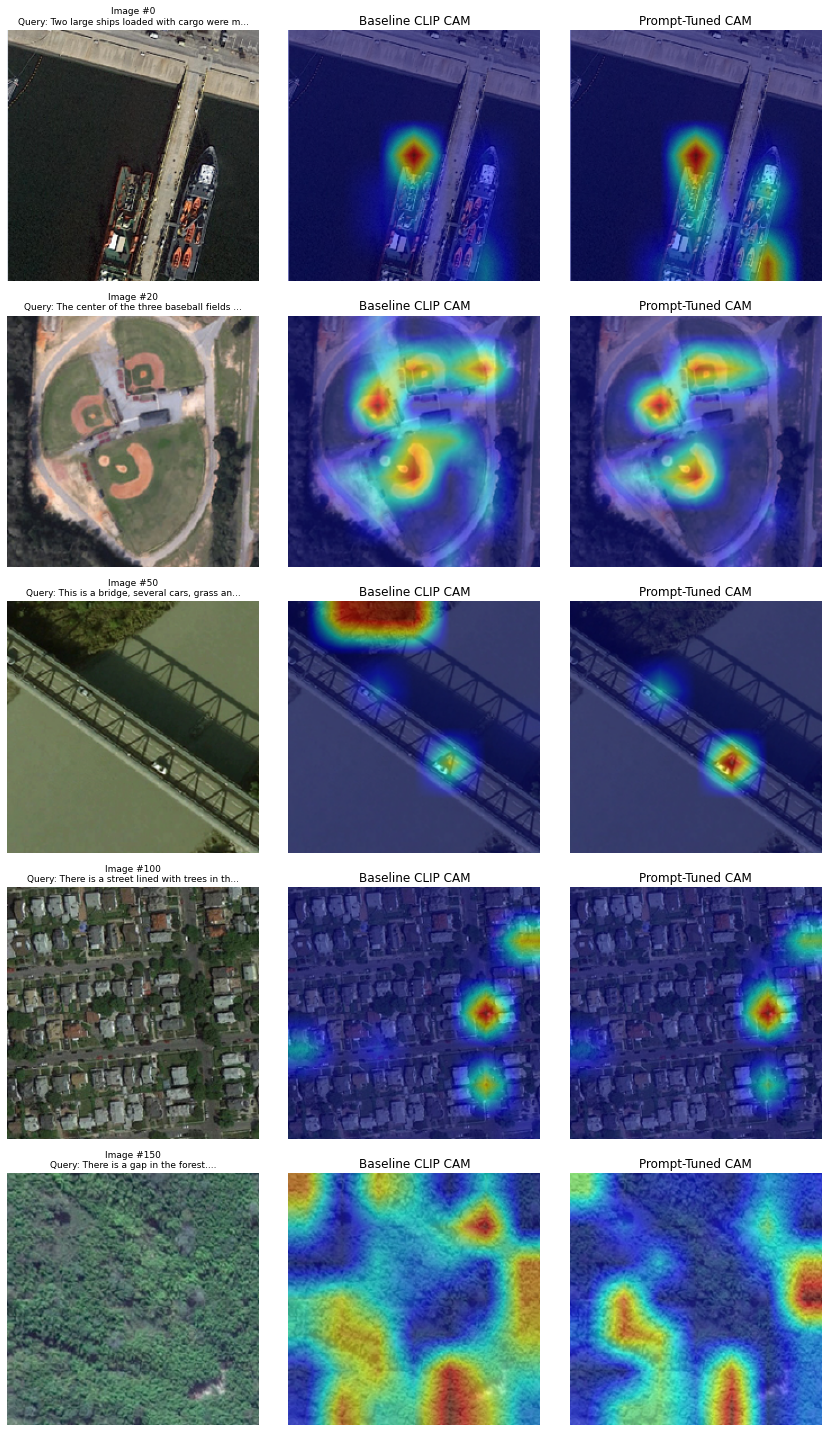

✅ GradCAM 图已保存（基于图文相似度，已修复 grad_fn 问题）


In [11]:
# ⚠️ 原代码 bug 复盘
# (1) `model` 与 `prompt_model.clip` 是同一对象；Prompt Tuning 不动视觉编码器，
#     所以"基线 vs 微调"的 CAM 必相同 → 改为对【图像 ↔ 某条文本余弦相似度】做 CAM
# (2) 上一版仍报 "element 0 of tensors does not require grad" —— 因为 CLIP 全参
#     被冻结，且 GradCAM 默认不会给输入张量打 requires_grad=True，导致 autograd
#     链整条断掉。修复办法：手动在输入上调用 .requires_grad_(True)
# (3) reshape_transform 兼容 [B,L,D] 和 [L,B,D] 两种 activation 布局，
#     避免不同 open_clip 版本下形状错位

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image


class ImageTextSimilarity(nn.Module):
    """forward 输出 [B,1] 余弦相似度标量；GradCAM 把它当 score 反传"""
    def __init__(self, clip_model, text_feat):
        super().__init__()
        self.clip = clip_model
        self.register_buffer('text_feat', text_feat)   # [D]

    def forward(self, x):
        img_feat = self.clip.encode_image(x).float()
        img_feat = F.normalize(img_feat, dim=-1)
        return img_feat @ self.text_feat.unsqueeze(-1)  # [B, 1]


# ViT 的 reshape：把 token 序列还原成 (H, W) 网格。兼容 batch_first 与 sequence-first
def vit_reshape_transform(tensor, height=7, width=7):
    n_tokens = height * width + 1                  # +1 是 CLS
    if tensor.shape[0] == n_tokens:                # [L, B, D] → 转到 [B, L, D]
        tensor = tensor.transpose(0, 1)
    # tensor 现在是 [B, L, D]
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    return result.permute(0, 3, 1, 2)              # [B, D, H, W]


def compute_text_feat(encoder_fn, text):
    with torch.no_grad():
        feat = encoder_fn([text])
        return F.normalize(feat.float(), dim=-1).squeeze(0)   # [D]


def baseline_text_encode(texts):
    tokens = tokenizer(texts).to(device)
    return model.encode_text(tokens)

def tuned_text_encode(texts):
    return prompt_model.encode_text_with_prompt(texts)


# 二者指向同一对象，但写明白避免歧义
visual_backbone = model
target_layers   = [visual_backbone.visual.transformer.resblocks[-1].ln_1]

DEMO_INDICES = [0, 20, 50, 100, 150]

fig, axes = plt.subplots(len(DEMO_INDICES), 3,
                         figsize=(12, 4 * len(DEMO_INDICES)))

for row, idx in enumerate(DEMO_INDICES):
    img_tensor, caps = test_dataset_full[idx]
    target_text = caps[0]                           # 取第 1 条 GT 描述当 query

    img_pil = Image.open(os.path.join(IMG_DIR,
                test_dataset_full.data[idx]['filename']))\
                .convert('RGB').resize((224, 224))
    img_np = np.array(img_pil)

    base_feat  = compute_text_feat(baseline_text_encode, target_text)
    tuned_feat = compute_text_feat(tuned_text_encode,    target_text)

    sim_base  = ImageTextSimilarity(visual_backbone, base_feat ).to(device).eval()
    sim_tuned = ImageTextSimilarity(visual_backbone, tuned_feat).to(device).eval()

    cam_base  = GradCAM(model=sim_base,  target_layers=target_layers,
                        reshape_transform=vit_reshape_transform)
    cam_tuned = GradCAM(model=sim_tuned, target_layers=target_layers,
                        reshape_transform=vit_reshape_transform)

    # ✅ 关键修复：CLIP 全参冻结，必须显式让输入张量 requires_grad=True，
    #              否则 autograd 链断掉，loss.backward() 会报无 grad_fn
    inp = img_tensor.unsqueeze(0).to(device).requires_grad_(True)

    g_base  = cam_base (input_tensor=inp, targets=None)[0]
    g_tuned = cam_tuned(input_tensor=inp, targets=None)[0]

    overlay_base  = show_cam_on_image(img_np / 255., g_base,  use_rgb=True)
    overlay_tuned = show_cam_on_image(img_np / 255., g_tuned, use_rgb=True)

    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title(f'Image #{idx}\nQuery: {target_text[:40]}...', fontsize=9)
    axes[row, 1].imshow(overlay_base);  axes[row, 1].set_title('Baseline CLIP CAM')
    axes[row, 2].imshow(overlay_tuned); axes[row, 2].set_title('Prompt-Tuned CAM')
    for ax in axes[row]:
        ax.axis('off')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/gradcam_comparison.png', dpi=150)
plt.show()
print("✅ GradCAM 图已保存（基于图文相似度，已修复 grad_fn 问题）")

In [13]:
import json

trainable = sum(p.numel() for p in prompt_model.parameters() if p.requires_grad)

results_summary = {
    "model":    "ViT-B-32 + Prompt Tuning (n_ctx=8)",
    "dataset":  "RSITMD Test",
    "baseline": baseline,
    "finetuned": final,
    "improvement": {
        k: round(final[k] - baseline[k], 2) for k in ['R@1', 'R@5', 'R@10']
    },
    "trainable_params": trainable,
    "total_params": 151_000_000,
}

with open(f'{SAVE_DIR}/results.json', 'w') as f:
    json.dump(results_summary, f, indent=2, ensure_ascii=False)

print("✅ 所有文件保存到:", SAVE_DIR)
print(f"   ├── best_prompt.pt")
print(f"   ├── training_curve.png")
print(f"   ├── gradcam_comparison.png")
print(f"   └── results.json")



✅ 所有文件保存到: /root/autodl-tmp/remote_clip
   ├── best_prompt.pt
   ├── training_curve.png
   ├── gradcam_comparison.png
   └── results.json
